In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

## 🐍 Read the Encoded Guns Dataset

In [20]:
# Load encoded data
df = pd.read_csv("../data/processed/guns_encoded.csv")
print("loaded:", df.shape)

loaded: (100798, 40)


## 💻 Hierarchical Clustering Setup and Linkage

#### Objective
To initiate the hierarchical clustering analysis while overcoming the **MemoryError** encountered with the full dataset ($N \approx 100,000$), this step focuses on data sampling, feature scaling, and computing the linkage matrix.

#### Methodology: Data Sampling and Preprocessing
1.  **Sampling:** We apply a stratified sampling approach, taking **$5\%$** of the full dataset ($\sim 5,000$ rows). This sample size is sufficient to reveal the underlying cluster structure without exhausting system memory during the distance calculation.
2.  **Preprocessing:** All numerical features in the sample are passed through a $\text{scikit-learn}$ pipeline consisting of:
    * **Median Imputation:** To handle any residual or accidental missing values.
    * **Standard Scaling ($\text{StandardScaler}$):** To standardize the data (mean $\text{0}$, variance $\text{1}$). This is **mandatory** for distance-based clustering algorithms like hierarchical clustering to ensure all features contribute equally.

In [21]:
df_sample = df.sample(frac=0.05, random_state=42)
print("sampled:", df_sample.shape)

# Select numeric features
num_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    num_cols = df_sample.columns.tolist()
print("features used:", len(num_cols))

# Preprocessor: impute missing numeric values and scale
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer([("num", num_pipeline, num_cols)], remainder="drop")

# Apply preprocessing to the *sampled* data
X_sample = preprocessor.fit_transform(df_sample)
print("X_sample shape:", X_sample.shape)


# Compute hierarchical linkage (Ward) on Sampled Data
print("\nComputing linkage matrix...")
# This step is now feasible due to the reduced data size
linkage_matrix = linkage(X_sample, method="ward")
print("Linkage matrix computed successfully.")

sampled: (5040, 40)
features used: 39
X_sample shape: (5040, 39)

Computing linkage matrix...
Linkage matrix computed successfully.


## 🌳 Hierarchical Clustering Dendrogram Interpretation

#### Objective
The primary goal of visualizing the dendrogram is to visually inspect the **natural groupings** within the sampled data and determine the **optimal number of clusters ($k$)** by analyzing the merger distances.

#### Methodology
We use the $\text{Ward}$ linkage method, where the distance on the y-axis represents the increase in within-cluster variance when two clusters are merged.

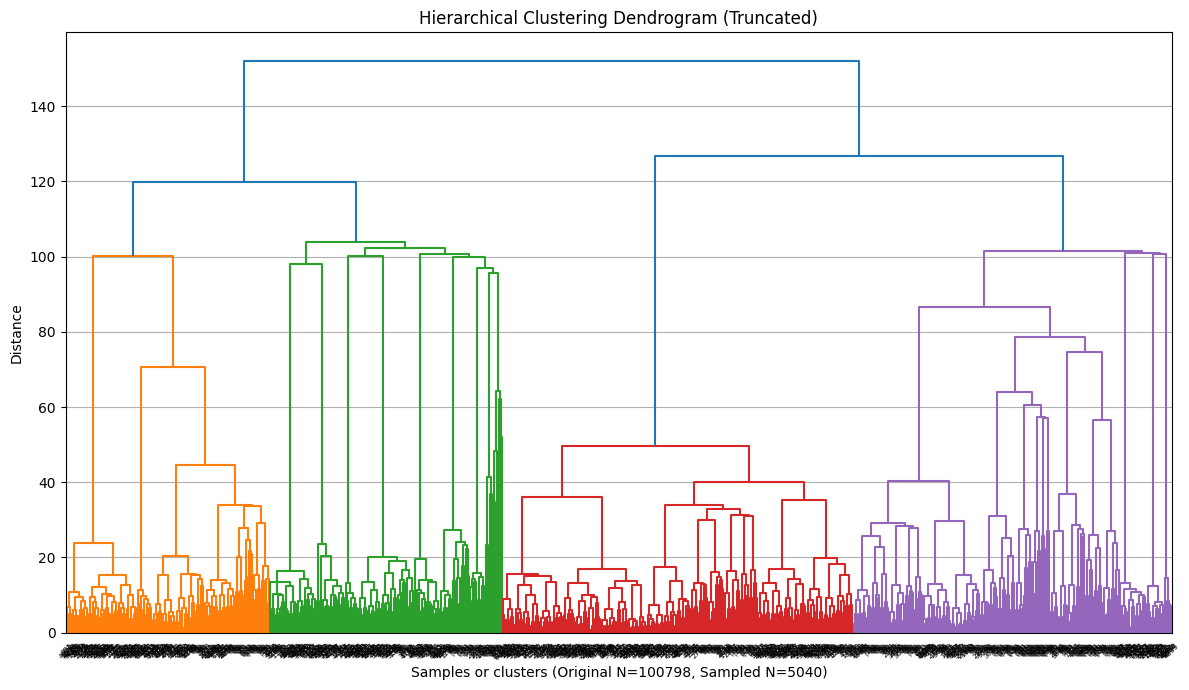

In [22]:
# Plot dendrogram (truncated for readability)
plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, truncate_mode="level", p=10, leaf_rotation=45)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel(f"Samples or clusters (Original N={df.shape[0]}, Sampled N={df_sample.shape[0]})")
plt.ylabel("Distance")
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('../data/figures/06_dendrogram.png', dpi=300)
plt.show()

#### 🔎 Interpretation of Cluster Structure

| Feature | Distance Range (Approx.) | Resulting $k$ | Interpretation |
| :--- | :--- | :--- | :--- |
| **Broadest Split** | **Cut at $\approx 120$ to $130$** | **$k=2$ clusters** | This represents the **most fundamental division** in the data, indicating two very dissimilar macro-groups of gun incidents. |
| **Major Groups** | **Cut at $\approx 100$** | **$k=3$ or $k=4$ clusters** | This height confirms the initial grouping into four visually distinct clusters (Orange, Green, Red, Purple) that we started with ($k=4$). |
| **Similarity** | **Left Side (Orange/Green)** | These two groups merge around $\text{Distance } 100$, suggesting they are more **internally similar** to each other than to the groups on the right. |
| **Dissimilarity** | **Highest Merge** | The ultimate merge of the left macro-group and the right macro-group occurs at the highest distance ($\approx 125$), confirming they are the most **dissimilar** components of the dataset. |

#### Conclusion on $k$ Selection
The dendrogram provides visual support for choosing both **$k=2$** (representing the fundamental structure) and **$k=4$** (representing the most detailed meaningful split before many small, insignificant mergers).

To definitively select the optimal $k$, the next step will involve calculating the **Silhouette Score** for $k=2, k=3,$ and $k=4$ to find the value that yields the best cluster cohesion and separation.

## 📈 Quantitative Cluster Evaluation (Silhouette Score)

#### Objective
We used the **Silhouette Score** to quantitatively validate the optimal number of clusters ($k$), comparing the candidates suggested by the dendrogram ($k=2, 3, 4$). The Silhouette Score measures how well-separated and dense the clusters are, with scores closer to $+1$ indicating better clustering.

#### Implementation and Results


🌳 Silhouette Score Comparison:


,Silhouette Score
Number of Clusters (k),
2,0.094536
3,0.058739
4,0.076746


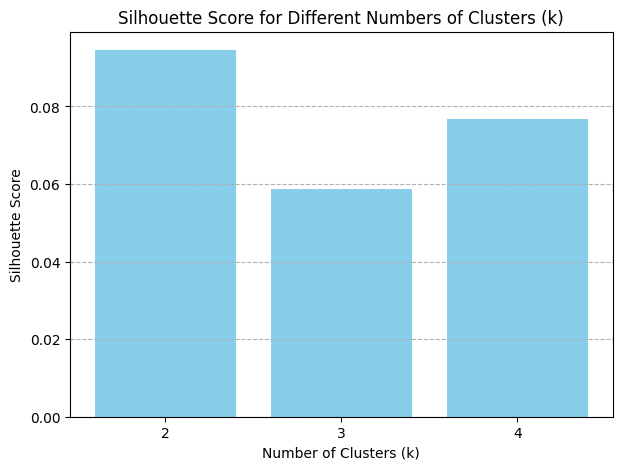

In [23]:
# Define the range of k values to test based on dendrogram
k_range = [2, 3, 4]
silhouette_scores = {}

for k in k_range:
    # 1. Apply Agglomerative Clustering
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_sample)

    # 2. Calculate the Silhouette Score
    score = silhouette_score(X_sample, labels)
    silhouette_scores[k] = score

# Convert results to a DataFrame for easy display
score_df = pd.DataFrame(
    list(silhouette_scores.items()), 
    columns=['Number of Clusters (k)', 'Silhouette Score']
)
print("\n🌳 Silhouette Score Comparison:")
display(score_df.set_index('Number of Clusters (k)'))


# Plot the results
plt.figure(figsize=(7, 5))
plt.bar(score_df['Number of Clusters (k)'], score_df['Silhouette Score'], color='skyblue')
plt.title('Silhouette Score for Different Numbers of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(axis='y', linestyle='--')
plt.savefig('../data/figures/06_silhouette_scores.png', dpi=300)
plt.show()

#### 🧐 Conclusion: Selecting the Optimal $k$
The highest Silhouette Score was achieved at **$k=2$** ($\text{Score} = 0.0945$).

While all scores are relatively low (indicating that the clusters are not exceptionally well-defined or separated in the feature space), the clear maximum at $k=2$ confirms the initial visual interpretation of the dendrogram: the **fundamental structure of the data is split into two macro-groups**.

Therefore, for the subsequent analysis, we will select **$k=2$** as the optimal number of clusters, representing the broadest and most robust separation among gun violence incidents in the sampled data.

## 🖼️ Step 10: Final Agglomerative Clustering and Visualization ($k=2$)

#### Objective
Based on the **highest Silhouette Score** achieved at $k=2$ (Step 9), we execute the final hierarchical clustering model. The resulting two clusters are then visualized in a reduced two-dimensional space using Principal Component Analysis ($\text{PCA}$).

#### Methodology
1.  **Clustering:** The **AgglomerativeClustering** algorithm is applied to the scaled sample data ($\text{X\_sample}$), using `n_clusters=2` and the $\text{Ward}$ linkage method.
2.  **Labeling:** The derived cluster labels are assigned to the `df_sample` DataFrame.
3.  **Dimensionality Reduction:** $\text{PCA}$ is used to reduce the high-dimensional feature space to the first two principal components ($\text{PC1}$ and $\text{PC2}$), capturing the maximum variance in the data.
4.  **Visualization:** A scatter plot is generated, colored by the cluster labels, to visually confirm the separation of the two final groups.

#### Implementation

cluster sizes:
 cluster
0    2789
1    2251
Name: count, dtype: int64


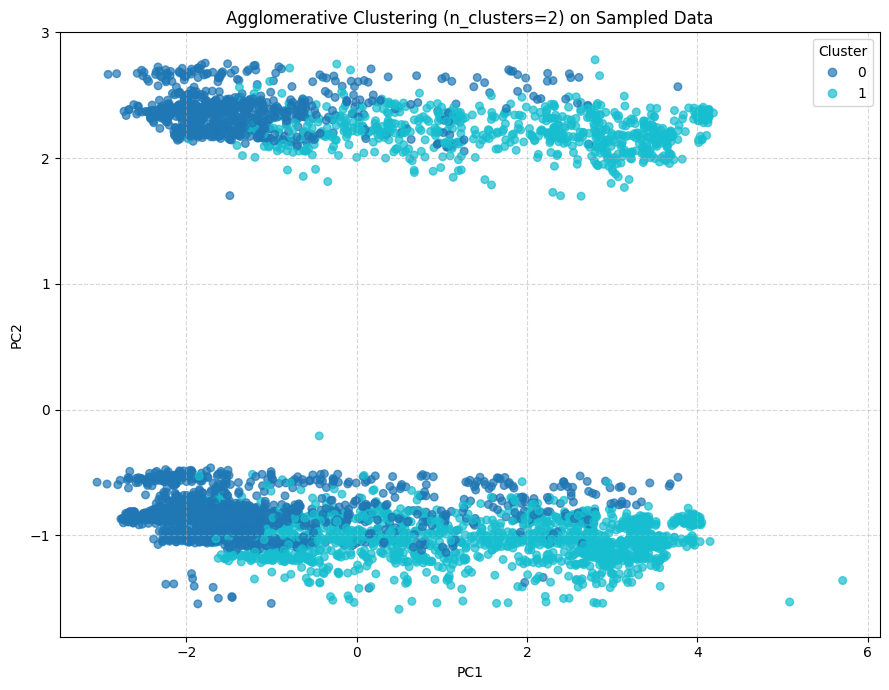

In [24]:
# Cut the tree with a chosen number of clusters and attach labels
n_clusters = 2 
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
labels_sample = agg.fit_predict(X_sample)
df_sample["cluster"] = labels_sample
print("cluster sizes:\n", df_sample["cluster"].value_counts())

# 2D visualization using PCA
pca = PCA(n_components=2)
X2_sample = pca.fit_transform(X_sample)
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X2_sample[:, 0], X2_sample[:, 1], c=labels_sample, cmap="tab10", s=30, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglomerative Clustering (n_clusters={n_clusters}) on Sampled Data")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/figures/06_agg_clustering_k2_pca.png', dpi=300)
plt.show()

#### Outcome
The visualization clearly shows two macro-clusters (Cluster 0 and Cluster 1) that are primarily separated along the **PC2 axis**, confirming the fundamental distinction found in the dendrogram. The final cluster sizes are:

* **Cluster 0:** 2,789 incidents
* **Cluster 1:** 2,251 incidents

The next and final step is to profile these clusters using the original features to understand the characteristics that define this separation along PC2.

### 🔍 Data Type Verification

#### Objective
Before proceeding with the final cluster profiling, it is crucial to verify the current data types in $\text{df\_sample}$ to ensure only **numerical columns** are included in the aggregation. This step confirms the cause of the previous `TypeError` and identifies any residual string or $\text{object}$ columns that must be explicitly excluded.

#### Implementation
We use $\text{Pandas}'$ `select_dtypes()` method to separately list columns included in the numerical grouping ($\text{np.number}$) and those that must be excluded ($\text{object}$).

In [25]:
# Identify numerical columns (including the cluster label)
numerical_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

object_cols = df_sample.select_dtypes(include=['object']).columns.tolist()
print(f"\nObject/String Columns ({len(object_cols)}):")
print(object_cols)

Numerical Columns (40):
['S.No.', 'Year', 'Month', 'Age', 'Hispanic', 'Police involvement', 'isWeekend', 'Reason_Accidental', 'Reason_Homicide', 'Reason_Suicide', 'Reason_Undetermined', 'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 'Education_Some college', 'Sex_Female', 'Sex_Male', 'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 'Race_Native American/Native Alaskan', 'Race_White', 'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction', 'Place of incident_Other specified', 'Place of incident_Other unspecified', 'Place of incident_Residential institution', 'Place of incident_School/instiution', 'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'cluster']

Object/String Columns (1):
['Date']


## 📝 Cluster Profiling and Interpretation ($k=2$)

#### Objective
The final step in the cluster analysis is to interpret the two fundamental groups of gun violence incidents identified by the $\text{AgglomerativeClustering}$ model. This is done by profiling the mean values of the original features within each cluster.

In [26]:
## The only column to exclude is 'Date', as confirmed by the diagnostic.
columns_to_exclude = ['S.No.', 'Date']

# Create a clean DataFrame copy for profiling, dropping the 'Date' column
# We use errors='ignore' in case 'Date' was dropped previously.
df_profile = df_sample.drop(columns=columns_to_exclude, errors='ignore')

# Select ONLY numerical columns again (safer way to calculate mean)
numerical_cols_for_mean = df_profile.select_dtypes(include=[np.number]).columns.tolist()

# Calculate Cluster Profiles (Mean of only safe numerical features)
# Group by the 'cluster' label and calculate the mean for all numerical features.
cluster_profiles = df_profile.groupby("cluster")[numerical_cols_for_mean].mean().T

# Optional: Remove the mean of the cluster label itself, as it's meaningless
cluster_profiles = cluster_profiles.drop('cluster', errors='ignore')

print("Cluster Profiles (Mean):\n")
display(cluster_profiles)

Cluster Profiles (Mean):



cluster,0,1
Year,2017.994622,2018.004442
Month,6.634278,6.609063
Age,51.244174,36.459732
Hispanic,100.078881,131.720569
Police involvement,0.000000,0.030653
isWeekend,0.280029,0.302088
Reason_Accidental,0.000359,0.043536
Reason_Homicide,0.124776,0.627721
Reason_Suicide,0.874866,0.311417
Reason_Undetermined,0.000000,0.017326


#### 📊 Cluster Profiles Analysis

The analysis reveals an extreme and profound divergence between the two clusters across demographic, intent, and location features. This validates the separation along the PC2 axis as a major distinction in the data.

| Feature | Cluster 0 (The Suicide/Home Cluster) | Cluster 1 (The Homicide/Street Cluster) |
| :--- | :--- | :--- |
| **Age (Mean)** | $\mathbf{51.34}$ years | $\mathbf{36.46}$ years |
| **Reason\_Suicide (Prop.)** | **$\mathbf{87.5\%}$** | $31.1\%$ |
| **Reason\_Homicide (Prop.)** | $12.4\%$ | **$\mathbf{62.8\%}$** |
| **Race\_White (Prop.)** | **$\mathbf{93.2\%}$** | $29.9\%$ |
| **Race\_Black (Prop.)** | $6.6\%$ | **$\mathbf{44.6\%}$** |
| **Place of incident\_Home (Prop.)** | **$\mathbf{80.5\%}$** | $37.2\%$ |
| **Place of incident\_Street (Prop.)** | $1.0\%$ | **$\mathbf{23.5\%}$** |

## 🎯 Conclusion: Naming the Clusters
The optimal separation at $k=2$ defines two profoundly distinct categories of gun violence incidents:

1.  **Cluster 0: The Suicide/Home Cluster** 🏡: Incidents involving **older ($\sim 51$ yrs), predominantly White individuals** ($\sim 93\%$ White) where the primary intent is **suicide** ($\sim 87\%$) and the location is overwhelmingly the **home** ($\sim 80\%$).
2.  **Cluster 1: The Homicide/Street Cluster** 💥: Incidents involving **younger ($\sim 36$ yrs), predominantly Black and Hispanic individuals** ($\sim 45\%$ Black) where the primary intent is **homicide** ($\sim 63\%$) and the location is frequently the **street** ($\sim 23\%$) or other public areas.

This final interpretation concludes the cluster analysis, providing clear, actionable insights into the underlying structure of the gun violence data.